# Exercise 1.6 — The distribution, as code

Rebuilding the *real-degrees* and *two-distributions* explorables from week 1, using the Marvel superhero network (Wikipedia `Category:Marvel Comics superheroes`, week-1 snapshot).

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

## 1. Load the week-1 Marvel snapshot as a directed graph

Data from the course data page: `week1_nodes.tsv` (303 characters) and `week1_edges.tsv` (edge `A -> B` whenever A's article links to B's).

Nodes are added **first**, from the full roster, so the 17 characters with no links in or out survive as isolates instead of silently disappearing.

Note: `week1_edges.tsv`'s header line is itself written as `# source\ttarget`, so a plain `pd.read_csv(..., comment='#')` would treat that header as a comment and eat the first data row as column names instead. We pass `header=None, names=[...]` explicitly to sidestep that.

In [2]:
nodes = pd.read_csv("data/week1_nodes.tsv", sep="\t", comment="#")
edges = pd.read_csv("data/week1_edges.tsv", sep="\t", comment="#",
                     header=None, names=["source", "target"])

name_of = dict(zip(nodes.node_id, nodes.name))

G = nx.DiGraph()
G.add_nodes_from(nodes.node_id)          # every node first, so isolates survive
G.add_edges_from(edges.itertuples(index=False))

n = G.number_of_nodes()
m_dir = G.number_of_edges()
n_isolates = len(list(nx.isolates(G)))

print(f"n = {n} (expected 303)")
print(f"directed edges = {m_dir} (expected 1784)")
print(f"isolates = {n_isolates} (expected 17)")

assert n == 303 and m_dir == 1784 and n_isolates == 17

n = 303 (expected 303)
directed edges = 1784 (expected 1784)
isolates = 17 (expected 17)


## 2. Reconcile with Part 2: collapse to undirected

In [3]:
Gu = G.to_undirected(reciprocal=False)
m_undir = Gu.number_of_edges()
avg_k = 2 * m_undir / n

print(f"undirected edges m = {m_undir} (expected 1434)")
print(f"average degree <k> = {avg_k:.4f} (expected \u2248 9.5)")

assert m_undir == 1434

undirected edges m = 1434 (expected 1434)
average degree <k> = 9.4653 (expected ≈ 9.5)


In [4]:
# Why 1784 directed edges become 1434 undirected ones
mutual_pairs = sum(1 for u, v in G.edges() if u < v and G.has_edge(v, u))
one_way = sum(1 for u, v in G.edges() if not G.has_edge(v, u))

print(f"mutual (reciprocated) pairs: {mutual_pairs}")
print(f"one-way directed edges: {one_way}")
print(f"check 2*mutual + one_way = {2*mutual_pairs + one_way} (should be 1784)")
print(f"check mutual + one_way   = {mutual_pairs + one_way} (should be 1434)")

mutual (reciprocated) pairs: 350
one-way directed edges: 1084
check 2*mutual + one_way = 1784 (should be 1784)
check mutual + one_way   = 1434 (should be 1434)


**Why the counts differ (one sentence):** 350 character pairs link to each other in *both* directions, so those 700 directed edges collapse into 350 single undirected edges, shrinking the total from 1784 directed edges down to 1434 undirected ones (350 + 1084 one-way edges).

## 3. Real-degrees explorable: in-degree and out-degree distributions

Plotted against $k+1$ (not $k$) so that the isolates, which have $k=0$, still show up on a log axis — $\log(0)$ is undefined, but $\log(k+1)$ is fine down to $k=0$.

In [5]:
in_deg = np.array([d for _, d in G.in_degree()])
out_deg = np.array([d for _, d in G.out_degree()])

in_kp1 = in_deg + 1
out_kp1 = out_deg + 1

def degree_scatter(kp1_values):
    """One point per observed value of k+1, with its count."""
    vals, counts = np.unique(kp1_values, return_counts=True)
    return vals, counts

in_x, in_y = degree_scatter(in_kp1)
out_x, out_y = degree_scatter(out_kp1)

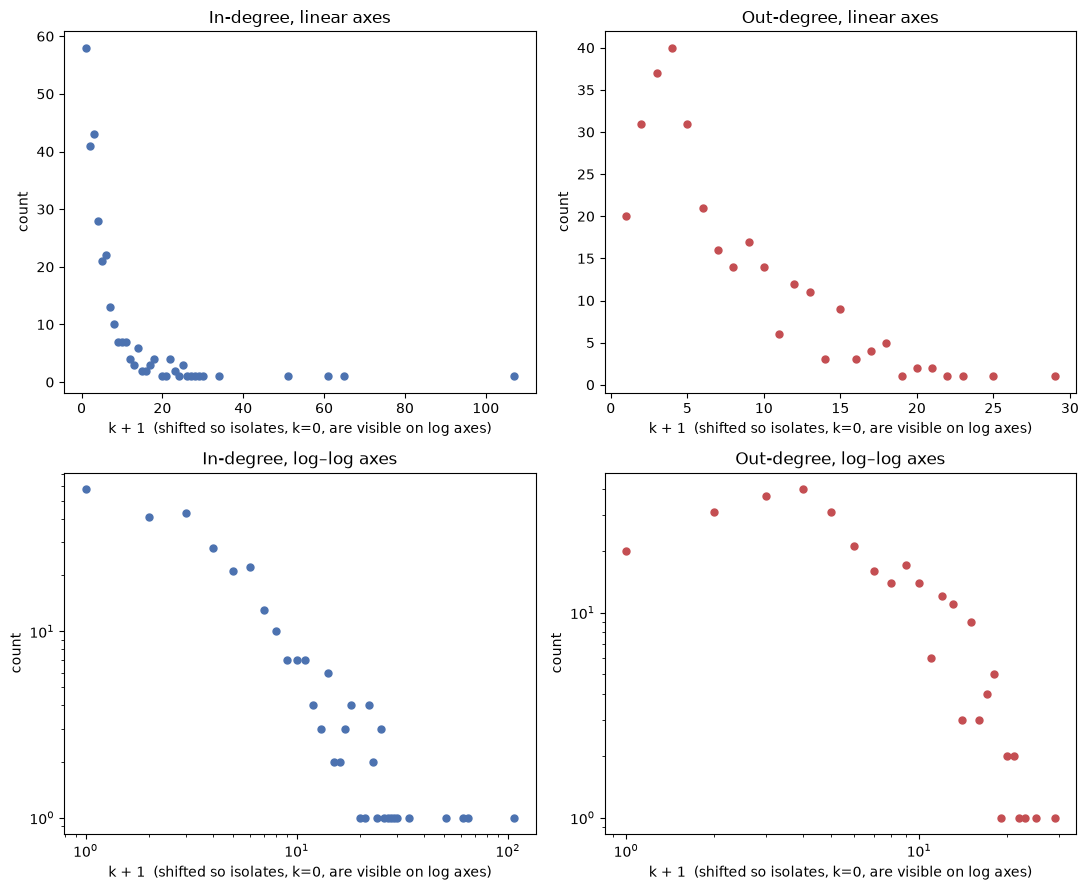

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# linear axes
axes[0, 0].scatter(in_x, in_y, color="#4C72B0", s=25)
axes[0, 0].set_title("In-degree, linear axes")

axes[0, 1].scatter(out_x, out_y, color="#C44E52", s=25)
axes[0, 1].set_title("Out-degree, linear axes")

# log-log axes
axes[1, 0].scatter(in_x, in_y, color="#4C72B0", s=25)
axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("In-degree, log–log axes")

axes[1, 1].scatter(out_x, out_y, color="#C44E52", s=25)
axes[1, 1].set_xscale("log")
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Out-degree, log–log axes")

for ax in axes.flat:
    ax.set_xlabel("k + 1  (shifted so isolates, k=0, are visible on log axes)")
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

In [7]:
def top5(deg_array, node_order):
    pairs = sorted(zip(node_order, deg_array), key=lambda p: -p[1])[:5]
    return [(name_of[node], d) for node, d in pairs]

node_order = list(G.nodes())
print("Top 5 by in-degree:")
for name, d in top5(in_deg, node_order):
    print(f"  {name}: {d}")

print("\nTop 5 by out-degree:")
for name, d in top5(out_deg, node_order):
    print(f"  {name}: {d}")

print("\nCompare this against the real-degrees explorable's leaderboard on the course page — same frozen snapshot, so it should match exactly.")

Top 5 by in-degree:
  Spider-Man: 106
  Hulk: 64
  Wolverine (character): 60
  Doctor Strange: 50
  Deadpool: 33

Top 5 by out-degree:
  Betsy Braddock: 28
  Cloak and Dagger (characters): 24
  Adam Warlock: 22
  Venom (character): 21
  She-Hulk: 20

Compare this against the real-degrees explorable's leaderboard on the course page — same frozen snapshot, so it should match exactly.


## 4. The Goodies: logarithmic binning

Scheme: width-1 bins for $k+1$ up to 7, then bins that double in width from there on. Each bin's count is divided by its width, and it's drawn at the geometric mean of the *integer degree values it spans* (not the geometric mean of the raw bin edges) — that's what makes it coincide exactly with the raw scatter wherever bins still have width 1.

In [8]:
def log_bin_edges(max_val, width1_max=7):
    edges = list(range(1, width1_max + 1))  # width-1 bins: 1,2,...,width1_max
    while edges[-1] < max_val:
        edges.append(edges[-1] * 2)         # then double each time
    return np.array(edges)

def log_binned_distribution(values, width1_max=7):
    values = np.asarray(values)
    edges = log_bin_edges(values.max(), width1_max)
    counts, _ = np.histogram(values, bins=edges)
    widths = np.diff(edges)
    x = np.empty(len(edges) - 1)
    for i in range(len(edges) - 1):
        span = np.arange(edges[i], edges[i + 1])
        if len(span) == 1:
            x[i] = span[0]  # avoid an exp(log(.)) round-trip when there's nothing to average
        else:
            x[i] = np.exp(np.mean(np.log(span)))
    y = counts / widths
    mask = counts > 0
    return x[mask], y[mask]

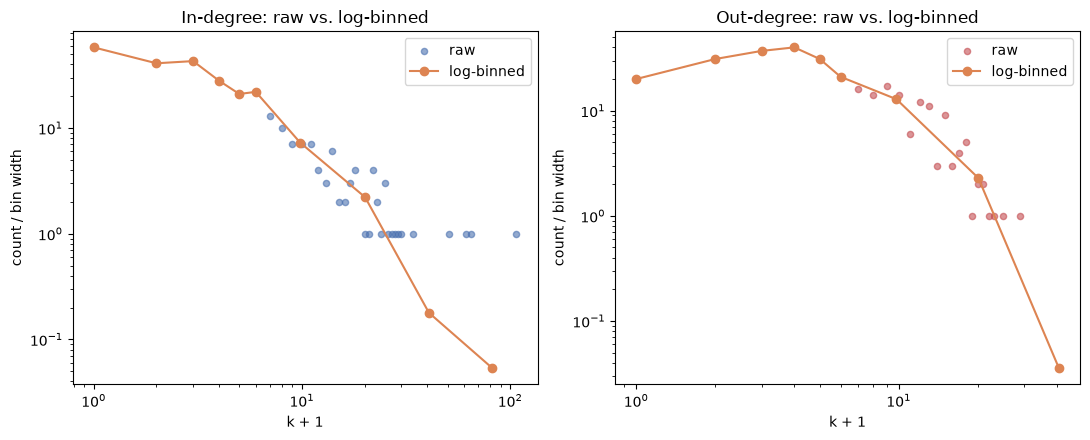

In [9]:
in_bin_x, in_bin_y = log_binned_distribution(in_kp1)
out_bin_x, out_bin_y = log_binned_distribution(out_kp1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(in_x, in_y, color="#4C72B0", s=20, label="raw", alpha=0.6)
axes[0].plot(in_bin_x, in_bin_y, "o-", color="#DD8452", label="log-binned")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_title("In-degree: raw vs. log-binned")
axes[0].legend()

axes[1].scatter(out_x, out_y, color="#C44E52", s=20, label="raw", alpha=0.6)
axes[1].plot(out_bin_x, out_bin_y, "o-", color="#DD8452", label="log-binned")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_title("Out-degree: raw vs. log-binned")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("k + 1")
    ax.set_ylabel("count / bin width")

plt.tight_layout()
plt.show()

In [10]:
# Numeric check: in the width-1 region (k+1 = 1..6), binned points must equal the raw counts exactly.
print(f"{'k+1':>5} {'raw count':>10} {'binned x':>10} {'binned y':>10}")
for i in range(6):
    raw_y = in_y[in_x == round(in_bin_x[i])][0]
    print(f"{round(in_bin_x[i]):>5} {raw_y:>10} {in_bin_x[i]:>10.4f} {in_bin_y[i]:>10.4f}")
    assert in_bin_x[i] == round(in_bin_x[i]) and in_bin_y[i] == raw_y
print("\nWidth-1 bins coincide exactly with the raw scatter, as expected.")

  k+1  raw count   binned x   binned y
    1         58     1.0000    58.0000
    2         41     2.0000    41.0000
    3         43     3.0000    43.0000
    4         28     4.0000    28.0000
    5         21     5.0000    21.0000
    6         22     6.0000    22.0000

Width-1 bins coincide exactly with the raw scatter, as expected.


## 5. Two distributions: exponential vs. power law

10,000 samples each, drawn by inverse-transform sampling:

- **Exponential**, rate $\lambda$: built into NumPy (`rng.exponential`).
- **Power law**, $p(x) \propto x^{-\alpha}$ for $x \ge x_{min}$: inverse CDF is $x = x_{min}(1-u)^{-1/(\alpha-1)}$ for $u \sim \mathrm{Uniform}(0,1)$.

In [11]:
rng = np.random.default_rng(42)

N = 10_000
expo_samples = rng.exponential(scale=5.0, size=N)

alpha, xmin = 2.5, 1.0
u = rng.random(N)
powerlaw_samples = xmin * (1 - u) ** (-1 / (alpha - 1))

print("exponential: min={:.3f} max={:.3f} mean={:.3f}".format(
    expo_samples.min(), expo_samples.max(), expo_samples.mean()))
print("power law:   min={:.3f} max={:.3f} mean={:.3f}".format(
    powerlaw_samples.min(), powerlaw_samples.max(), powerlaw_samples.mean()))

exponential: min=0.000 max=47.591 mean=4.944
power law:   min=1.000 max=711.038 mean=3.035


In [12]:
def general_log_binned_pdf(values, bins=30):
    """General-purpose log-binned density estimate for continuous, positive data."""
    values = np.asarray(values)
    values = values[values > 0]
    edges = np.geomspace(values.min(), values.max(), bins + 1)
    counts, _ = np.histogram(values, bins=edges)
    widths = np.diff(edges)
    x = np.sqrt(edges[:-1] * edges[1:])  # geometric mean of bin edges
    y = counts / widths / len(values)    # normalized to a density
    mask = counts > 0
    return x[mask], y[mask]

expo_x, expo_y = general_log_binned_pdf(expo_samples)
pl_x, pl_y = general_log_binned_pdf(powerlaw_samples)

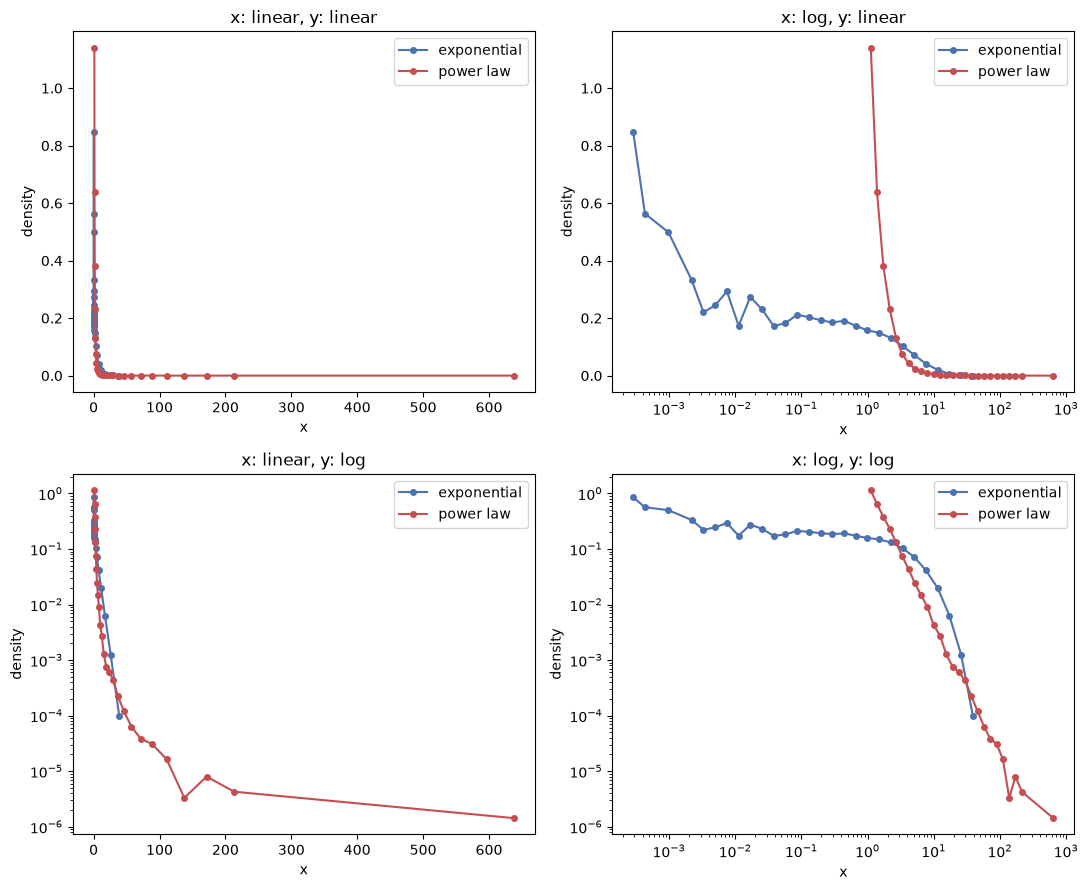

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

combos = [
    ("linear", "linear"),
    ("log", "linear"),
    ("linear", "log"),
    ("log", "log"),
]

for ax, (xscale, yscale) in zip(axes.flat, combos):
    ax.plot(expo_x, expo_y, "o-", color="#4C72B0", label="exponential", markersize=4)
    ax.plot(pl_x, pl_y, "o-", color="#C44E52", label="power law", markersize=4)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.set_title(f"x: {xscale}, y: {yscale}")
    ax.set_xlabel("x")
    ax.set_ylabel("density")
    ax.legend()

plt.tight_layout()
plt.show()

**Look at the four panels above and confirm with your own eyes:**
- The exponential curve should look straight in the panel with a *linear x-axis and log y-axis* (an exponential's log is a straight line: $\log p(x) = \log \lambda - \lambda x$).
- The power law should look straight in the panel with *both axes log* (a power law's log-log plot is a straight line: $\log p(x) = \log C - \alpha \log x$).

Check that this is actually what you see — don't just take the formulas' word for it.

### Now overlay the real in-degree distribution on the same axes

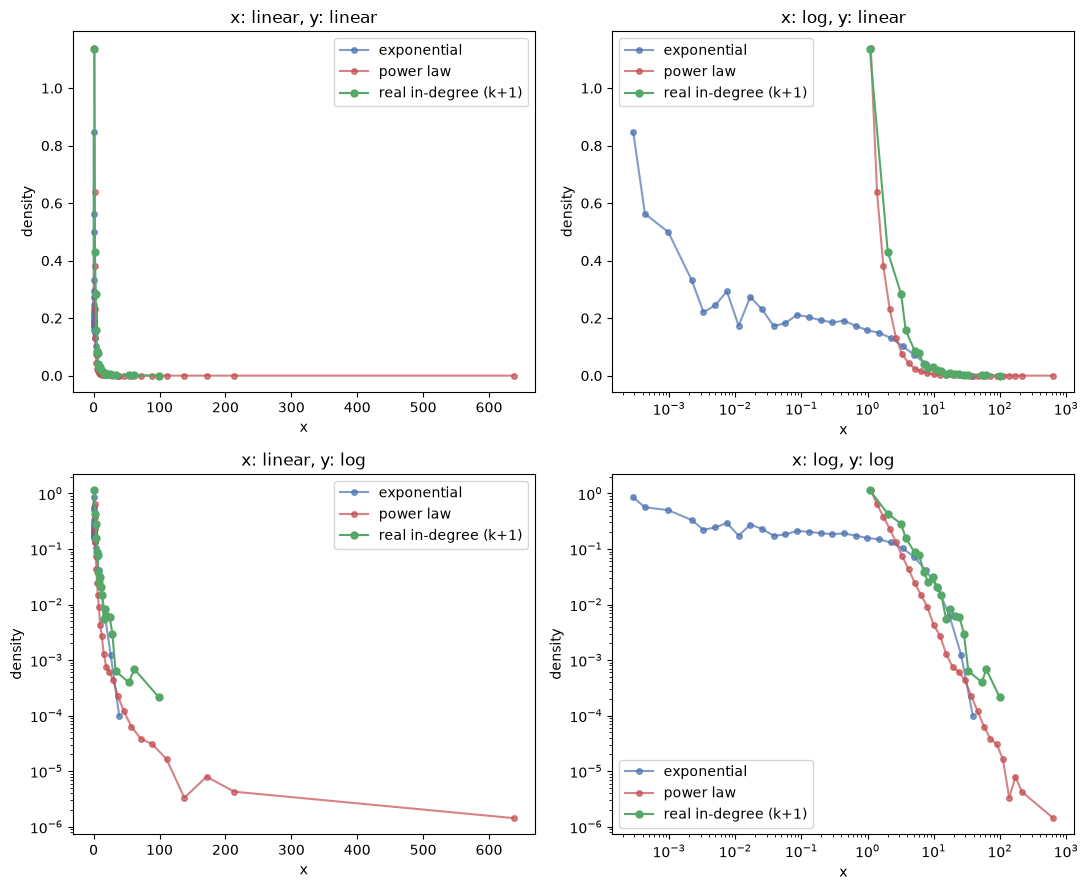

In [14]:
real_x, real_y = general_log_binned_pdf(in_kp1)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for ax, (xscale, yscale) in zip(axes.flat, combos):
    ax.plot(expo_x, expo_y, "o-", color="#4C72B0", label="exponential", markersize=4, alpha=0.7)
    ax.plot(pl_x, pl_y, "o-", color="#C44E52", label="power law", markersize=4, alpha=0.7)
    ax.plot(real_x, real_y, "o-", color="#55A868", label="real in-degree (k+1)", markersize=5)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.set_title(f"x: {xscale}, y: {yscale}")
    ax.set_xlabel("x")
    ax.set_ylabel("density")
    ax.legend()

plt.tight_layout()
plt.show()

**Your call:** looking at the log–log panel especially — does the real in-degree distribution's shape track the power law's straight line, the exponential's curve, or neither convincingly? Note the sample-size mismatch (303 real nodes vs. 10,000 synthetic samples each) before over-interpreting the tail.

*My answer (fill in after looking at the plot):* —

*How sure am I (1–5):* —

*(We'll dig into this more rigorously — fitting exponents, goodness of fit — in week 2.)*